In [1]:
import sys

# Necessary to import from src dir
sys.path.append('../..')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import re
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix
)

from src.logistic_regression import (
    model_predict_binary,
    plot_sigmoid,
    run_lasso_logistic_regression
)
from src.preprocessing import prepare_standardized_datasets

In [3]:
DATA_DIR = r"./../data/"
OUTPUT_DIR = r"./../outputs/"

TRAIN_DATA = os.path.join(DATA_DIR, "train.csv")
TEST_DATA = os.path.join(DATA_DIR, "test.csv")

# Preprocessing

df_train = pd.read_csv(TRAIN_DATA)
df_test = pd.read_csv(TEST_DATA)

label_var = "class4"

# Include only the real-valued mean values, but don't exclude anything further than that yet before exploring the data a bit first
cols_to_include = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat == label_var)]

numeric_vars = cols_to_include[:]
numeric_vars.remove(label_var)

df_train_standardized, df_validation_standardized, df_test_standardized = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

df_train_standardized.head()

,class4,class2,CO2168.mean,CO2336.mean,CO242.mean,CO2504.mean,Glob.mean,H2O168.mean,H2O336.mean,H2O42.mean,...,SO2168.mean,SWS.mean,T168.mean,T42.mean,T504.mean,T672.mean,T84.mean,UV_A.mean,UV_B.mean,CS.mean
0,nonevent,nonevent,-0.248367,-0.246893,-0.291424,-0.242811,-0.815977,0.909728,0.919800,0.881351,...,0.240907,-0.581092,0.598443,0.597351,0.606432,0.610143,0.589385,-0.626624,-0.628594,2.124704
1,II,event,-0.723427,-0.731410,-0.753980,-0.730752,1.157391,0.285260,0.268382,0.318118,...,-0.636594,-0.796493,0.609995,0.612423,0.617666,0.609105,0.611062,1.058974,1.534246,0.364594
2,Ib,event,-1.144919,-1.157368,-1.235564,-1.203221,1.787842,0.229090,0.218331,0.253849,...,-0.407569,0.497061,0.953328,0.972838,0.976511,0.972408,0.973183,1.634689,2.303497,0.522607
3,II,event,0.507035,0.514327,0.410856,0.530358,0.198127,0.008589,0.019077,-0.012565,...,-0.161154,0.246970,0.395949,0.405766,0.384316,0.384677,0.402635,0.257973,0.467223,0.305790
4,nonevent,nonevent,0.310836,0.278223,0.352405,0.253055,-0.883747,1.355479,1.378534,1.324064,...,-0.576377,0.339367,0.621757,0.635497,0.613279,0.615497,0.626640,-0.728473,-0.359808,0.157278


In [4]:
cols_to_include_extended = [feat for feat in df_train.columns.to_list() if (feat.endswith(".mean")) or (feat.endswith(".std")) or (feat == label_var)]
numeric_vars_extended = cols_to_include_extended[:]
numeric_vars_extended.remove(label_var)

In [24]:
def run_binary_logistic_regression_with_lasso(
    ax,
    training_data,
    test_data,
    data_vars=numeric_vars,
    label_var="class2",
    target_label="nonevent",
    inverse_label="event"
):
    X_train = training_data[data_vars]
    y_train = training_data[label_var]
    X_test = test_data[data_vars]
    y_test = test_data[label_var]

    lasso = run_lasso_logistic_regression(X_train, y_train)

    train_accuracy, test_accuracy = model_predict_binary(
        model=lasso,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test,
        target_label=target_label
    )
    
    print(f"LASSO train accuracy: {train_accuracy}")
    print(f"LASSO test accuracy: {test_accuracy}")

    plot_sigmoid(
        ax=ax,
        model=lasso,
        X_train=X_train,
        y_train=y_train,
        target_label=target_label,
        inverse_label=inverse_label
    )

    return lasso

LASSO train accuracy: 0.8888888888888888
LASSO test accuracy: 0.8777777777777778


Text(0.5, 0.98, 'Class2 Classification with all mean values')

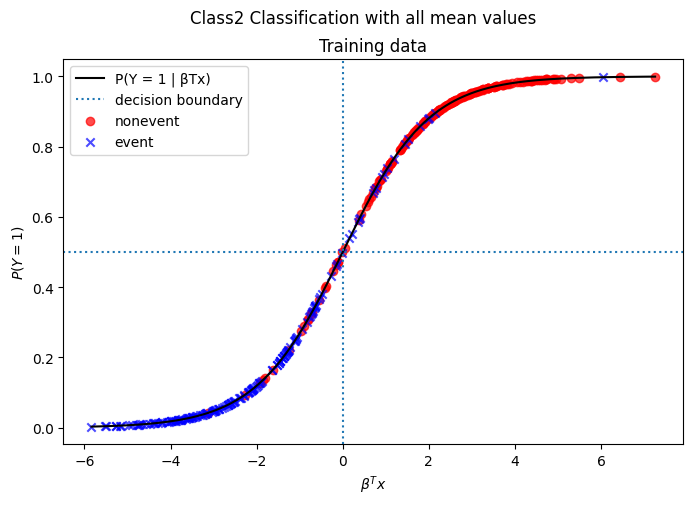

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_standardized,
    df_validation_standardized,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification with all mean values")

LASSO train accuracy: 0.8722222222222222
LASSO test accuracy: 0.8888888888888888


Text(0.5, 0.98, 'Class2 Classification with all mean & std values')

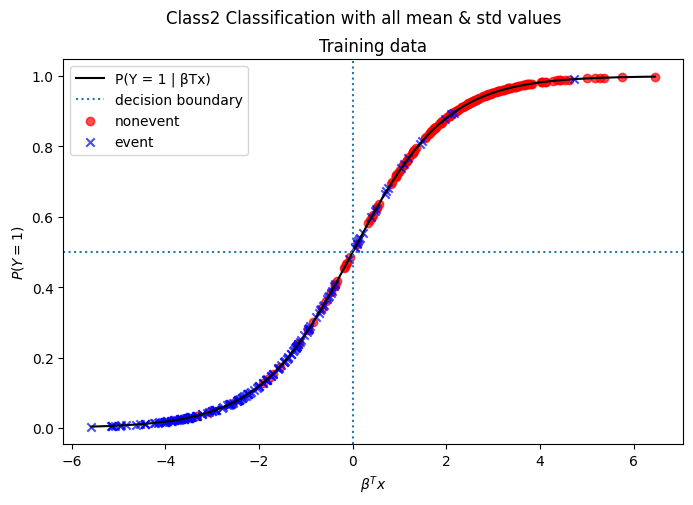

In [7]:
df_train_standardized_full, df_validation_standardized_full, _ = prepare_standardized_datasets(
    df_train=df_train,
    df_test=df_test,
    data_vars=numeric_vars_extended,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_standardized_full,
    df_validation_standardized_full,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification with all mean & std values")

### Drop event type II

Repeat the same process with reduced data. Because event type II has questionable accuracy, just use event type I in the binary classification (event vs. nonevent).

In [8]:
# Drop event type II events

df_train_reduced = df_train_standardized.drop(df_train_standardized[df_train_standardized["class4"] == "II"].index)
df_validation_reduced = df_validation_standardized.drop(df_validation_standardized[df_validation_standardized["class4"] == "II"].index)

LASSO train accuracy: 0.9144981412639405
LASSO test accuracy: 0.890625


Text(0.5, 0.98, 'Class2 classification with event types I vs. nonevents')

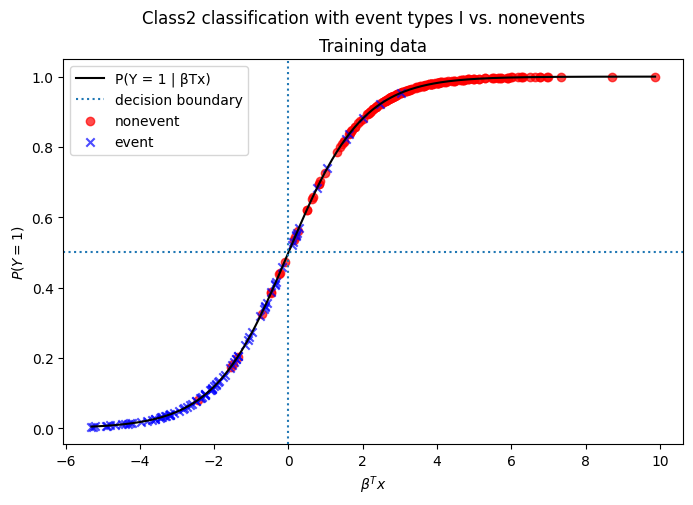

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_train_reduced,
    df_validation_reduced,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 classification with event types I vs. nonevents")

### Drop event type II + oversample event types Ia and Ib

In [10]:
ros = RandomOverSampler(random_state=0)
X_train_ros, y_train_ros = ros.fit_resample(df_train_reduced[numeric_vars], df_train_reduced["class2"])
df_X_ros = pd.DataFrame(X_train_ros, columns=numeric_vars)
df_X_ros["class2"] = y_train_ros

LASSO train accuracy: 0.919889502762431
LASSO test accuracy: 0.9375


Text(0.5, 0.98, 'Class2 classification with event types I vs. nonevents and oversampling')

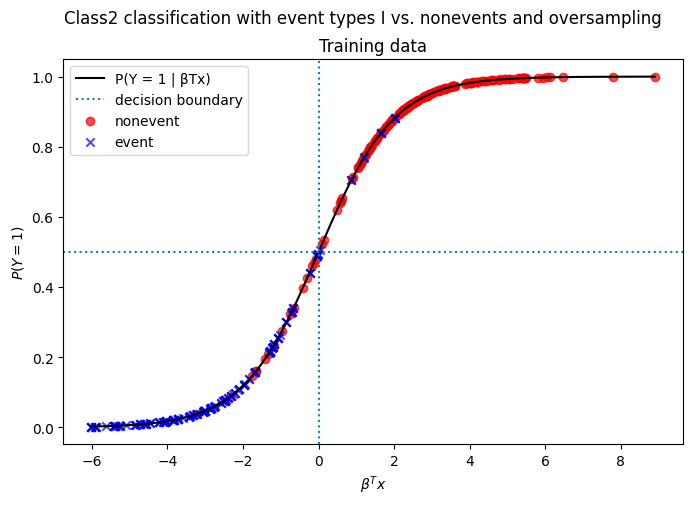

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
run_binary_logistic_regression_with_lasso(
    ax,
    df_X_ros,
    df_validation_reduced,
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 classification with event types I vs. nonevents and oversampling")

### Combine redundant data columns

In [12]:
def combine_columns(
    df_train,
    patterns
):
    for col, pattern in patterns.items():
        cols_to_combine = []
        for feat in df_train.columns.to_list():
            matches = re.findall(pattern, feat)
            if len(matches) > 0:
                cols_to_combine = cols_to_combine + matches
    
        if len(cols_to_combine) > 1:
            df_train[col] = df_train[cols_to_combine].mean(axis=1)
    
            df_train = df_train.drop(columns=cols_to_combine)

    return df_train

In [22]:
patterns = {
    "CO2_combined.mean": rf"CO2\d{{2,3}}.mean",
    "H2O_combined.mean": rf"H2O\d{{2,3}}.mean",
    "NO_combined.mean": rf"NO\d{{2,3}}.mean",
    "NOx_combined.mean": rf"NOx\d{{2,3}}.mean",
    "O3_combined.mean": rf"O3\d{{2,3}}.mean",
    "RHIRGA_combined.mean": rf"RHIRGA\d{{2,3}}.mean",
    "T_combined.mean": rf"T\d{{2,3}}.mean"
}

df_train_combine = combine_columns(df_train, patterns)
df_test_combine = combine_columns(df_test, patterns)

combined_numeric_vars = [feat for feat in df_train_combine.columns.to_list() if (feat.endswith(".mean"))]

LASSO train accuracy: 0.8972222222222223
LASSO test accuracy: 0.8888888888888888


Text(0.5, 0.98, 'Class2 Classification combined mean & std values')

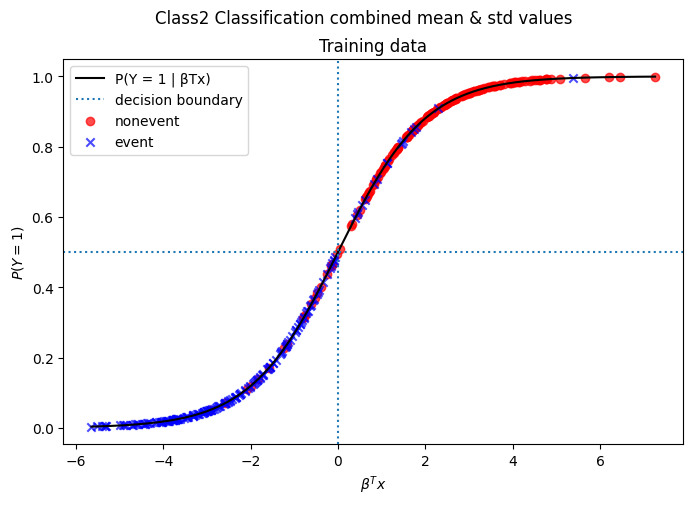

In [38]:
df_train_combo, df_validation_combo, df_test_combo = prepare_standardized_datasets(
    df_train=df_train_combine,
    df_test=df_test_combine,
    data_vars=combined_numeric_vars,
    label_var=label_var,
    label_values=("nonevent", "event"),
    include_validation_split=True,
    validation_split_size=0.2
)

fig, ax = plt.subplots(figsize=(8, 5))
event2_model = run_binary_logistic_regression_with_lasso(
    ax,
    df_train_combo,
    df_validation_combo,
    data_vars=combined_numeric_vars,
    label_var="class2",
    target_label="nonevent",
    inverse_label="event"
)
fig.suptitle("Class2 Classification combined mean & std values")

## Event4 classification

In [36]:
event4_lasso = LogisticRegression(C=0.17, l1_ratio=1, solver='liblinear', max_iter=20000, class_weight='balanced')

In [37]:
y4_train = df_train_combo["class4"]
X_train = df_train_combo[combined_numeric_vars]

event_mask_train = y4_train != "nonevent"
X_train_events = X_train[event_mask_train]
y_train_events = y4_train[event_mask_train]
y_train_events = y_train_events.replace({'Ia': 'Ib'})

event4_lasso.fit(X_train_events, y_train_events)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.17
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",1
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term

## Reading and scaling the test data 

In [39]:
# Scaled test data
X_test_final = df_test_combo[combined_numeric_vars]

## Predicting on the test data

In [40]:
y_test_final_pred = event2_model.predict(X_test_final)
y_test_final_proba = event2_model.predict_proba(X_test_final)

#Scaling the data for event classification
y_test_final_ev_pred = event4_lasso.predict(X_test_final)

## Combining the predictions

In [43]:
#Use event prediction to fill the event type for samples predicted as event
class_4_pred = np.where(y_test_final_pred == 'event', y_test_final_ev_pred, 'nonevent')
#Combining the predictions into a dataframe for submission
classes = list(event2_model.classes_)
submission_df = pd.DataFrame({
    'id': df_test['id'],
    'class4': class_4_pred,
    'p': y_test_final_proba[:, classes.index('event')]
})
submission_df

,id,class4,p
0,450,Ib,0.639824
1,451,Ib,0.963857
2,452,nonevent,0.020014
3,453,nonevent,0.468667
4,454,Ib,0.852360
...,...,...,...
960,1410,nonevent,0.311408
961,1411,nonevent,0.110772
962,1412,II,0.884885
963,1413,nonevent,0.138603


In [45]:
submission_df.to_csv(r"./../outputs/submission_combined_means.csv", index=False)